In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [ ]:
import os
import shutil
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Đường dẫn đến thư mục chứa dữ liệu
data_dir = '/content/drive/MyDrive/dataset_egg_full'

# Kiểm tra xem thư mục mẹ tồn tại không
if not os.path.exists(data_dir):
    print("The specified directory does not exist.")
else:
    # Lấy danh sách tất cả các tệp ảnh từ tất cả các thư mục con
    all_image_files = []
    for subdir in os.listdir(data_dir):
        subdir_path = os.path.join(data_dir, subdir)
        if os.path.isdir(subdir_path):
            image_files = [os.path.join(subdir, file) for file in os.listdir(subdir_path) if file.endswith(".jpg")]
            all_image_files.extend(image_files)

    # Chia dữ liệu thành tập huấn luyện và tập validation_dataset (80/20)
    train_files, validation_files = train_test_split(all_image_files, test_size=0.2, random_state=42)

    # Tạo đường dẫn đến thư mục huấn luyện và xác thực
    train_dir = os.path.join(data_dir, 'train')
    validation_dir = os.path.join(data_dir, 'validation')

    # Tạo thư mục huấn luyện nếu nó không tồn tại
    if not os.path.exists(train_dir):
        os.makedirs(train_dir)

    # Tạo thư mục xác thực nếu nó không tồn tại
    if not os.path.exists(validation_dir):
        os.makedirs(validation_dir)

    # Di chuyển các tệp vào các thư mục tương ứng của tập huấn luyện và xác thực
    for file in train_files:
        src_file = os.path.join(data_dir, file)
        dst_file = os.path.join(train_dir, file)
        os.makedirs(os.path.dirname(dst_file), exist_ok=True)  # Tạo thư mục đích nếu không tồn tại
        shutil.copy(src_file, dst_file)

    for file in validation_files:
        src_file = os.path.join(data_dir, file)
        dst_file = os.path.join(validation_dir, file)
        os.makedirs(os.path.dirname(dst_file), exist_ok=True)  # Tạo thư mục đích nếu không tồn tại
        shutil.copy(src_file, dst_file)

    # Số lượng mẫu trong mỗi lô
    BATCH_SIZE = 32

    # Kích thước ảnh đầu vào
    IMG_SIZE = (160, 160)

    # Tạo dataset cho tập huấn luyện
    train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                                shuffle=True,
                                                                batch_size=BATCH_SIZE,
                                                                image_size=IMG_SIZE)

    # Tạo dataset cho tập xác thực
    validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                     shuffle=True,
                                                                     batch_size=BATCH_SIZE,
                                                                     image_size=IMG_SIZE)


Found 3164 files belonging to 4 classes.
Found 791 files belonging to 4 classes.


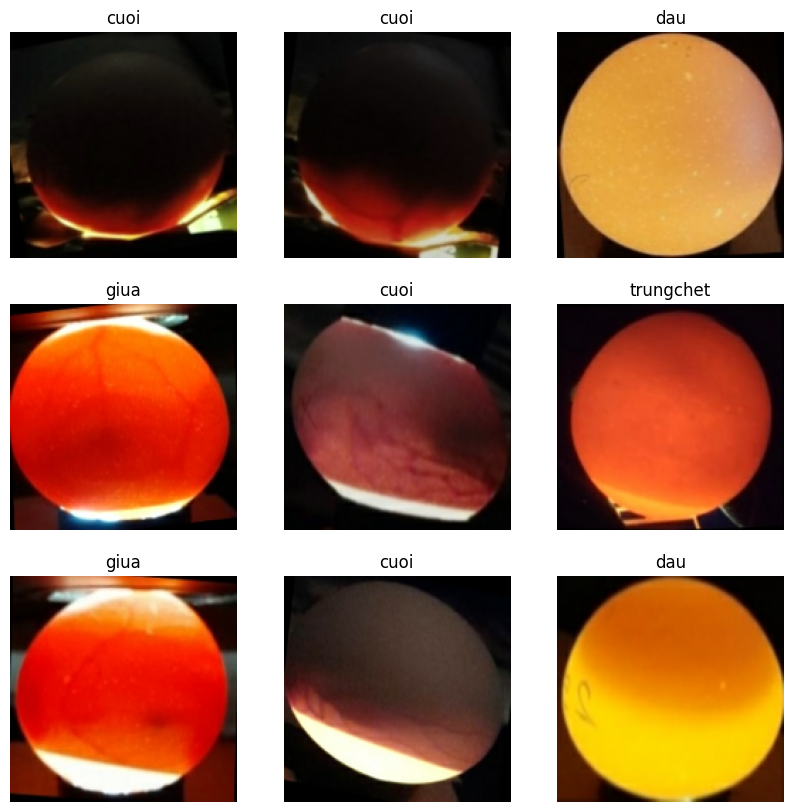

In [ ]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# val_batches = tf.data.experimental.cardinality(validation_dataset)
# test_dataset = validation_dataset.take(val_batches // 5)
# validation_dataset = validation_dataset.skip(val_batches // 5)

In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
# print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 25


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
# test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

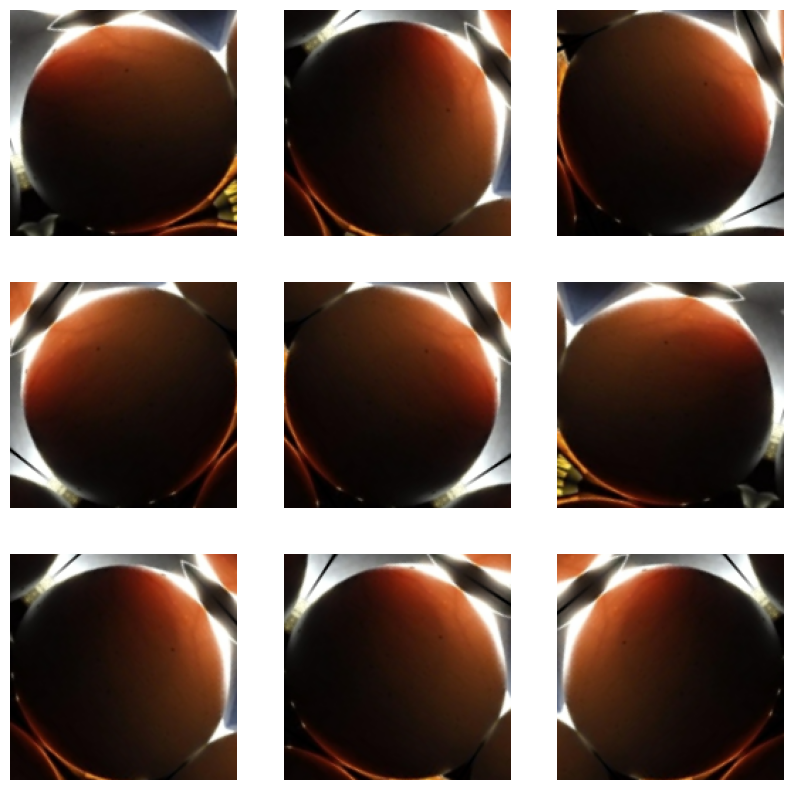

In [ ]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input


In [ ]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [ ]:
# Tạo mô hình cơ sở từ mô hình được đào tạo trước MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


In [ ]:
base_model.trainable = False

In [ ]:
# kiến ​​trúc mô hình cơ sở
base_model.summary()

Model: "mobilenetv2_1.00_160"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 160, 160, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 80, 80, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 80, 80, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 80, 80, 32)           0         ['bn_Conv1[

In [ ]:
#Giả sử feature_batch có kích thước (batch_size, height, width, channels). Lớp GlobalAveragePooling2D sẽ tính trung bình giá trị trên chiều height và width cho mỗi kênh (channel)
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [ ]:
# # Số lớp phân loại
# num_classes = len(class_names)

# # Tạo lớp kết nối đầy đủ mới với số nơ-ron bằng số lớp phân loại
# prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

# # Đưa feature_batch_average qua lớp kết nối đầy đủ để thu được prediction_batch
# prediction_batch = prediction_layer(feature_batch_average)

# # In ra hình dạng của prediction_batch
# print(prediction_batch.shape)


# Thêm lớp dropout
dropout_layer = tf.keras.layers.Dropout(0.2)
# Thêm lớp dự đoán với kích hoạt softmax để phân loại nhiều lớp
prediction_layer = tf.keras.layers.Dense(4, activation='softmax') #Tạo một lớp Dense (fully connected layer) với 4 đầu ra. Số 4 ở đây đại diện cho số lớp (classes) mà bạn muốn phân loại, softmax chuyển đổi các giá trị đầu ra của lớp Dense thành xác suất, sao cho tổng các xác suất của tất cả các lớp bằng 1
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)


(32, 4)


In [ ]:
# inputs = tf.keras.Input(shape=(160, 160, 3))
# x = data_augmentation(inputs)
# x = preprocess_input(x)
# x = base_model(x, training=False)
# x = global_average_layer(x)
# x = tf.keras.layers.Dropout(0.2)(x)
# outputs = prediction_layer(x)
# model = tf.keras.Model(inputs, outputs)
# Build the model
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False) #training=False cho phép mô hình chạy trong chế độ suy luận (inference), không cập nhật các trọng số của mô hình tiền huấn luyện trong quá trình huấn luyện.
x = global_average_layer(x)
x = dropout_layer(x) #Áp dụng Dropout để ngẫu nhiên tắt một số nơ-ron trong quá trình huấn luyện nhằm tránh overfitting
outputs = prediction_layer(x) #Thêm lớp dự đoán (ví dụ: Dense layer với softmax hoặc sigmoid activation) để tạo ra các đầu ra cuối cùng của mô hình
model = tf.keras.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 160, 160, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 160, 160, 3)       0         
 da)                                                             
                                                                 
 mobilenetv2_1.00_160 (Func  (None, 5, 5, 1280)        2257984   
 tional)                                                         
                                                             

In [ ]:
len(model.trainable_variables)

2

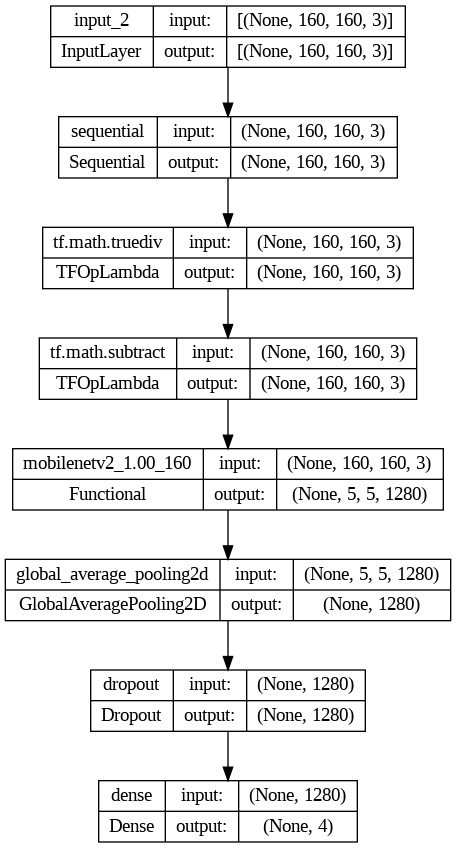

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# base_learning_rate = 0.0001
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
#               loss=tf.keras.losses.CategoricalCrossentropy(),
#               metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')])

base_learning_rate = 0.0001
# Compile mô hình với hàm mất mát là CategoricalCrossentropy
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])


In [ ]:
# initial_epochs = 10

# # Chuyển đổi nhãn thành dạng one-hot encoding
# def preprocess_dataset(images, labels):
#     labels = tf.one_hot(labels, num_classes)
#     return images, labels

# train_dataset = train_dataset.map(preprocess_dataset)
# validation_dataset = validation_dataset.map(preprocess_dataset)

# # Compile model
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
#               loss=tf.keras.losses.CategoricalCrossentropy(),
#               metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')])

# # Tiếp tục đánh giá mô hình
# loss0, accuracy0 = model.evaluate(validation_dataset)

# # Chuyển đổi nhãn của tập validation thành one-hot encoding
# validation_dataset_onehot = validation_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=4)))

initial_epochs = 100

loss0, accuracy0 = model.evaluate(validation_dataset)


25/25 [==============================] - 6s 100ms/step - loss: 1.8977 - accuracy: 0.2516


In [ ]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 1.90
initial accuracy: 0.25


In [ ]:
# Huấn luyện nè
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/100
99/99 [==============================] - 22s 156ms/step - loss: 1.3257 - accuracy: 0.4150 - val_loss: 0.8870 - val_accuracy: 0.6650
Epoch 2/100
99/99 [==============================] - 12s 119ms/step - loss: 0.8649 - accuracy: 0.6492 - val_loss: 0.6489 - val_accuracy: 0.7965
Epoch 3/100
99/99 [==============================] - 12s 119ms/step - loss: 0.6787 - accuracy: 0.7399 - val_loss: 0.5204 - val_accuracy: 0.8521
Epoch 4/100
99/99 [==============================] - 16s 151ms/step - loss: 0.5586 - accuracy: 0.8091 - val_loss: 0.4341 - val_accuracy: 0.8799
Epoch 5/100
99/99 [==============================] - 13s 121ms/step - loss: 0.4685 - accuracy: 0.8385 - val_loss: 0.3769 - val_accuracy: 0.9039
Epoch 6/100
99/99 [==============================] - 13s 125ms/step - loss: 0.4182 - accuracy: 0.8606 - val_loss: 0.3309 - val_accuracy: 0.9191
Epoch 7/100
99/99 [==============================] - 13s 123ms/step - loss: 0.3928 - accuracy: 0.8660 - val_loss: 0.3019 - val_accuracy:

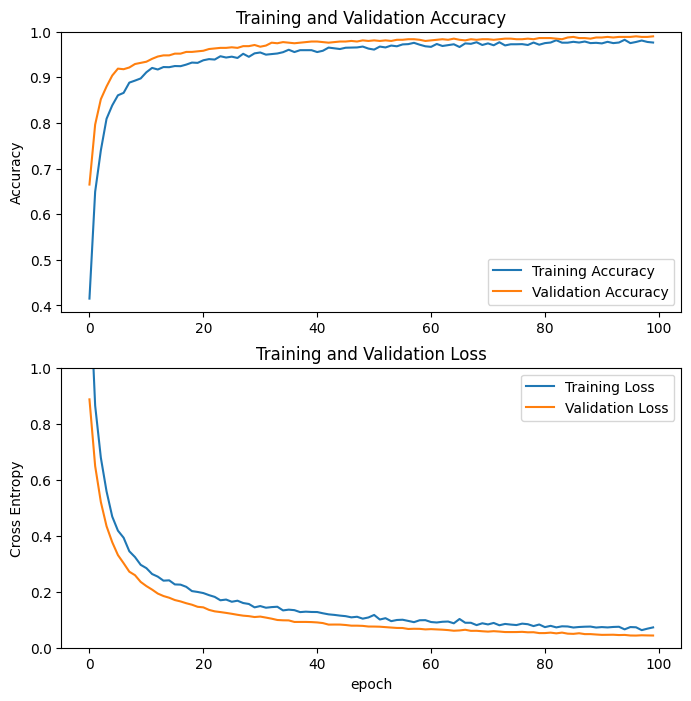

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
# xem mô hình cơ sở có bao nhiêu lớp
print("Number of layers in the base model: ", len(base_model.layers))

# Tinh chỉnh từ lớp này trở đi
fine_tune_at = 100

# Đóng băng tất cả các lớp trước lớp `fine_tune_at`
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [ ]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 160, 160, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 160, 160, 3)       0         
 da)                                                             
                                                                 
 mobilenetv2_1.00_160 (Func  (None, 5, 5, 1280)        2257984   
 tional)                                                         
                                                             

In [ ]:
len(model.trainable_variables)

56

In [ ]:
fine_tune_epochs = 100
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 101/200
99/99 [==============================] - 23s 135ms/step - loss: 0.0829 - accuracy: 0.9719 - val_loss: 0.0592 - val_accuracy: 0.9785
Epoch 102/200
99/99 [==============================] - 13s 125ms/step - loss: 0.0602 - accuracy: 0.9779 - val_loss: 0.0230 - val_accuracy: 0.9924
Epoch 103/200
99/99 [==============================] - 14s 132ms/step - loss: 0.0537 - accuracy: 0.9817 - val_loss: 0.0217 - val_accuracy: 0.9975
Epoch 104/200
99/99 [==============================] - 13s 127ms/step - loss: 0.0406 - accuracy: 0.9880 - val_loss: 0.0159 - val_accuracy: 0.9949
Epoch 105/200
99/99 [==============================] - 13s 125ms/step - loss: 0.0395 - accuracy: 0.9864 - val_loss: 0.0219 - val_accuracy: 0.9924
Epoch 106/200
99/99 [==============================] - 13s 121ms/step - loss: 0.0283 - accuracy: 0.9883 - val_loss: 0.0143 - val_accuracy: 0.9962
Epoch 107/200
99/99 [==============================] - 13s 124ms/step - loss: 0.0333 - accuracy: 0.9870 - val_loss: 0.0361 -

In [ ]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

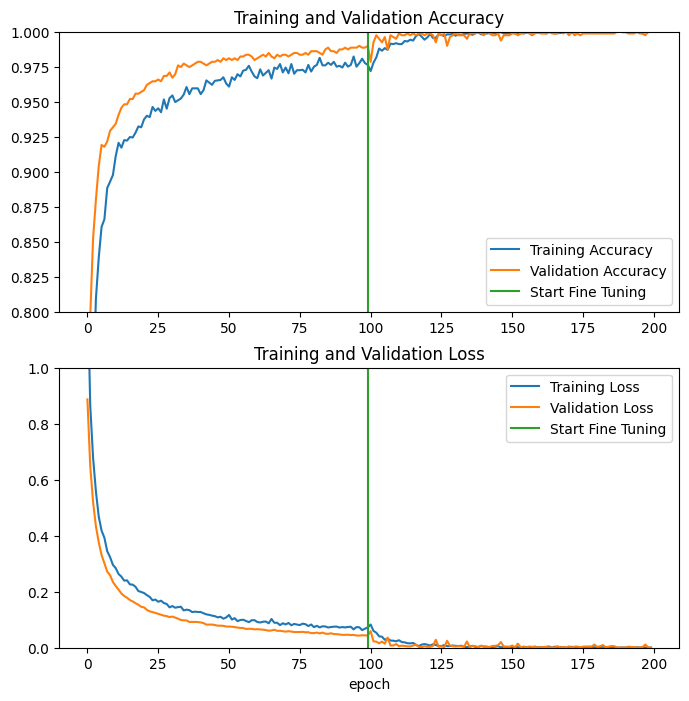

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
# Đường dẫn đến nơi bạn muốn lưu mô hình với định dạng .h5
model_save_path = '/content/drive/MyDrive/h5kl/mobinet.h5'

# Lưu mô hình dưới dạng file .h5
model.save(model_save_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# tải lên thư mục test data tạo từ một bộ dữ liệu riêng biệt nhằm tăng tính khách quan và thực tế cho mô hình khi test
import os
import tensorflow as tf

# Đường dẫn đến thư mục chứa dữ liệu
test_dir = '/content/drive/MyDrive/test_dataset'

# Kiểm tra xem thư mục mẹ tồn tại không
if not os.path.exists(test_dir):
    print("The specified directory does not exist.")
else:
    # Số lượng mẫu trong mỗi lô
    BATCH_SIZE = 32

    # Kích thước ảnh đầu vào
    IMG_SIZE = (160, 160)

    # Tạo dataset cho tập kiểm tra từ thư mục chứa ảnh
    test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir,
                                                                shuffle=True,
                                                                batch_size=BATCH_SIZE,
                                                                image_size=IMG_SIZE)


Found 50 files belonging to 4 classes.


In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

2/2 [==============================] - 23s 750ms/step - loss: 8.9698e-06 - accuracy: 1.0000
Test accuracy : 1.0


In [ ]:
import numpy as np
import tensorflow as tf

# Đường dẫn đến mô hình đã lưu
model_save_path = '/content/drive/MyDrive/h5kl/mobinet.h5'

# Tải lại mô hình
loaded_model = tf.keras.models.load_model(model_save_path)

# Load ảnh mới
image_path = '/content/drive/MyDrive/Bản sao của normalized_image_0.jpg'
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(160, 160))
image_array = tf.keras.preprocessing.image.img_to_array(image)
image_array = np.expand_dims(image_array, 0)  # Thêm chiều batch

# Class names
class_names = ['15-21', '0-7', '8-14', 'trungchet']

# Dự đoán
predictions = loaded_model.predict(image_array)
predicted_class_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_index]

print('Predicted class:', predicted_class)

print('Predicted class:', predicted_class_index)
print('Predicted class:', predictions)


1/1 [==============================] - 5s 5s/step
Predicted class: 0-7
Predicted class: 1
Predicted class: [[3.5407967e-21 1.0000000e+00 5.0859696e-19 2.5273561e-11]]
